# Notebook 00 · Sensor Preprocessing

**Goal:** Extract, clean, and temperature-compensate raw on-site sensor data.

The three independent disturbance phenomena handled by this notebook:

| Phenomenon | Nature | Filter |
|---|---|---|
| Power outage | Rows exist but `charge == 0`; signal reads `0` (hardware artefact) | Step 3a: removed first, before any signal analysis |
| Sudden spikes | One or more readings anomalously far from local signal context | Step 3b: rolling-median context filter |
| Temperature drift | Slow thermal bias on the structural reading | Step 3c: linear thermal compensation |

**Steps:**
1. **File Inspection** — Examine one raw file before loading.
2. **Data Loading** — Read all raw sensor files from `data/raw/sensor/`.
3. **Signal Cleaning and Compensation** — Power-loss removal → spike removal
   (rolling-median context filter) → temperature compensation.
4. **Compensation Visualisation** — Plot raw vs. compensated signal with
   dropped values highlighted.
5. **Save** — Export cleaned datasets to `data/interim/sensor/`.

## Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import glob
from IPython.display import display
sys.path.insert(0, os.path.abspath('..'))

from heritageshm.dataloader import inspect_raw_file, load_sensor_directory, organize_sensor_data
from heritageshm.preprocessing import process_station
from heritageshm.viz import apply_theme, plot_compensation_comparison

apply_theme(context='notebook')

## Step 1 · File Inspection

Inspect one representative raw file to confirm the delimiter, column count,
and date format before loading the entire directory.

### Parameter Tuning Guidance

| Parameter | Purpose | Accepted values | Default |
|---|---|---|---|
| `RAW_FOLDER` | Path to raw sensor files | Any valid path string | `'data/raw/sensor'` |
| `FILE_EXT` | Extension of raw files | Any string (e.g. `'.adc'`, `'.csv'`) | `'.adc'` |

In [2]:
RAW_FOLDER = 'data/raw/sensor'
FILE_EXT   = '.adc'

sample_files = glob.glob(os.path.join(RAW_FOLDER, f'*{FILE_EXT}'))
if sample_files:
    file_info = inspect_raw_file(sample_files[0])
else:
    print(f'No {FILE_EXT} files found in {RAW_FOLDER}. Check RAW_FOLDER and FILE_EXT.')
    file_info = {}


────────────────────────────────────────────────────────────
  FILE INSPECTION: GUBBIO_20180726.adc
────────────────────────────────────────────────────────────

  DETECTED STRUCTURE
  Delimiter             : 'TAB'
  Decimal symbol        : comma  ','  (European format — decimal_comma=True)
  Column count          : 14
  Header row            : None (header=None)
  Date format hint      : DD/MM/YY  (dayfirst=True)

  SUGGESTED CONFIGURATION
  SEPARATOR           = '\t'
  DECIMAL_COMMA       = True
  HEADER              = None
  # Expected columns  : 14

  FIRST 5 LINES (raw)
  ────────────────────────────────────────────────────────
  25/07/18	23:40:00	3,500	21,965	44,910	1942,625	3,490	21,750	45,115	2122,750	0,000	0,000	0,000	0,000
  26/07/18	00:00:00	3,500	21,695	45,220	1940,625	3,470	21,555	45,155	2122,125	3,480	20,870	50,095	2077,125
  26/07/18	00:20:00	0,000	0,000	0,000	0,000	3,470	21,365	45,040	2121,000	3,490	20,700	48,595	2076,625
  26/07/18	00:40:00	3,490	21,090	45,005	1936,12

## Step 2 · Load Raw Sensor Files

Read all files in the raw sensor directory and organise them into
per-station DataFrames.

### Parameter Tuning Guidance

| Parameter | Purpose | Accepted values | Default |
|---|---|---|---|
| `SEPARATOR` | Column delimiter | `'\\t'`, `';'`, `','` | `'\\t'` |
| `DECIMAL_COMMA` | Comma as decimal separator? | `True` / `False` | `True` |
| `HEADER` | Header row index or `None` | `0`, `None` | `None` |
| `STATIONS` | Station IDs → ordered column names | `dict[str, list[str]]` | see below |

In [3]:
SEPARATOR     = '\t'
DECIMAL_COMMA = True
HEADER        = None

STATIONS = {
    'st01': ['charge', 'temp', 'hum', 'absinc'],
    'st02': ['charge', 'temp', 'hum', 'absinc'],
    'st03': ['charge', 'temp', 'hum', 'absinc'],
}

df_raw = load_sensor_directory(
    folder_path=RAW_FOLDER,
    extension=FILE_EXT,
    sep=SEPARATOR,
    header=HEADER,
    decimal_comma=DECIMAL_COMMA,
    column_names=None,
    date_col=0,
    time_col=1,
    save_combined=False,
)

print(f'\nLoaded dataset shape : {df_raw.shape}')
print(f'Date range : {df_raw.index.min()} \u2192 {df_raw.index.max()}')

stations_dict = organize_sensor_data(df_raw, STATIONS)
print(f'Organised {len(stations_dict)} station(s): {list(stations_dict.keys())}')

Found 1911 files matching '.adc'. Processing...


Loading sensor data: 100%|██████████| 1911/1911 [00:57<00:00, 33.40it/s]



Loaded dataset shape : (132590, 12)
Date range : 2018-07-25 23:40:00 → 2025-02-05 12:20:00
Organised 3 station(s): ['st01', 'st02', 'st03']


## Step 3 · Signal Cleaning and Temperature Compensation

`process_station()` runs the four-stage physical pipeline in the correct order:

1. **Power-loss removal** — rows where `charge == 0` are hardware artefacts and
   are removed *first*, before the spike filter sees any signal values.  This
   guarantees that outage zeros never enter the rolling-median window and cannot
   corrupt spike classification.

2. **Spike removal (rolling-median context filter)** — each sample is compared
   against the *local median* of its nearest valid neighbours (within ±`SPIKE_WINDOW`
   positions).  This correctly handles:
   - **Isolated spikes**: large deviation on both sides → removed.
   - **Post-outage spike runs**: all spike rows deviate from pre-outage AND
     post-recovery context → removed.  The first clean recovery reading is
     close to its right-side neighbours → kept.
   - **Gap boundaries**: not enough valid neighbours → skipped (kept).

3. **Temperature compensation** — linear thermal correction using `COMP_COEFF`.
   Applied to the clean signal only.  Uses the first reading as the thermal
   baseline (trustworthy after steps 1 and 2).

4. **Normalisation** — series shifted so it starts at 0.

### Parameter Tuning Guidance

| Parameter | Purpose | Type | Default | Notes |
|---|---|---|---|---|
| `SIGNAL_COL` | Structural signal column | `str` | `'absinc'` | Must exist in every station |
| `TEMP_COL` | Temperature column | `str` | `'temp'` | Must exist in every station |
| `COMP_COEFF` | Thermal coefficient (mdeg·°C⁻¹·10⁻³) | `float` | `0.005` | From sensor calibration sheet |
| `SPIKE_THRESHOLD` | Max deviation from local median (mdeg) | `float > 0` | `500.0` | Start large, review dropped CSV, then tighten |
| `SPIKE_WINDOW` | Half-window: valid neighbours on each side | `int ≥ 1` | `7` | Larger = smoother reference; smaller = more local |
| `SPIKE_MIN_VALID` | Min neighbours required to evaluate a point | `int ≥ 1` | `3` | Points with fewer neighbours are always kept |
| `OUTPUT_DIR` | Interim CSV destination | `str` | `'data/interim/sensor'` | Created automatically |

In [4]:
SIGNAL_COL       = 'absinc'
TEMP_COL         = 'temp'
COMP_COEFF       = 0.005      # mdeg · °C⁻¹ · 10⁻³ — update from calibration sheet
SPIKE_THRESHOLD  = 500.0      # mdeg — deviation from local rolling median
SPIKE_WINDOW     = 7          # valid neighbours on each side
SPIKE_MIN_VALID  = 3          # minimum neighbours to evaluate a sample
OUTPUT_DIR       = 'data/interim/sensor'

processed = {}

for st, df_st in stations_dict.items():
    df_clean, _ = process_station(
        st=st,
        df_st=df_st,
        signal_col=SIGNAL_COL,
        temp_col=TEMP_COL,
        comp_coeff=COMP_COEFF,
        spike_threshold=SPIKE_THRESHOLD,
        output_dir=OUTPUT_DIR,
        window=SPIKE_WINDOW,
        min_valid=SPIKE_MIN_VALID,
    )
    processed[st] = df_clean


──────────────────────────────────────────────────
  Station : st01  |  raw rows: 132590
  Filter  : rolling-median  window=7  min_valid=3  threshold=500.0
──────────────────────────────────────────────────
  Dropped   48136 power-loss rows (zero charge in 'charge')
  Dropped      54 spike rows  (|deviation from local median| > 500.0, window=7, min_valid=3)
  Retained   84400 / 132590 rows (63.7 %)
  Saved  → data/interim/sensor\st01_preprocessed.csv
  Shape  : (84400, 5)  |  2018-07-25 23:40:00 → 2022-09-22 17:40:00
  Dropped → data/interim/sensor\st01_dropped.csv  (48190 rows)

──────────────────────────────────────────────────
  Station : st02  |  raw rows: 132590
  Filter  : rolling-median  window=7  min_valid=3  threshold=500.0
──────────────────────────────────────────────────
  Dropped   16028 power-loss rows (zero charge in 'charge')
  No spikes detected  (threshold=500.0, window=7)
  Retained  116562 / 132590 rows (87.9 %)
  Saved  → data/interim/sensor\st02_preprocessed.csv


## Step 4 · Compensation Visualisation

`plot_compensation_comparison()` loads the saved interim CSV directly so it
can be called at any time to inspect any station.

Dropped rows are overlaid in distinct colours:
**crimson** = spike removals; **darkviolet** = power-loss removals.

### Parameter Tuning Guidance

| Parameter | Purpose | Accepted values | Default | Notes |
|---|---|---|---|---|
| `VIZ_STATION` | Station to inspect | Any key in `STATIONS` | `'st02'` | |
| `VIZ_START` / `VIZ_END` | Zoom window | `'YYYY-MM-DD'` or `None` | `None` | `None` = full series |
| `DOT_SIZE` | Marker size for main signal scatter | `float > 0` | `2` | |
| `DROPPED_DOT_SIZE` | Marker size for dropped-value overlay | `float > 0` or `None` | `None` (= `DOT_SIZE × 4`) | Set explicitly to override |

Plot saved successfully to outputs/figures as 00_01_st02_compensation_comparison


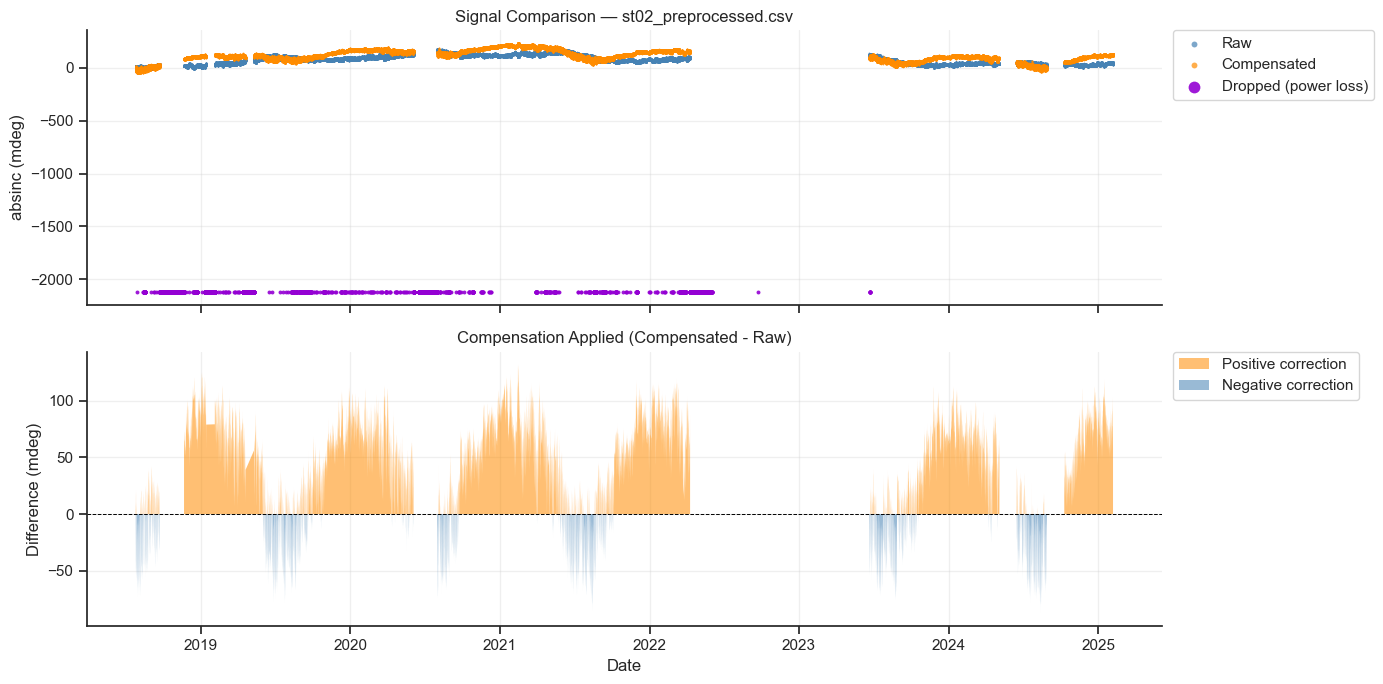

In [6]:
VIZ_STATION      = 'st02'
VIZ_START        = None
VIZ_END          = None
DOT_SIZE         = 2
DROPPED_DOT_SIZE = None   # None = DOT_SIZE * 4

viz_file     = os.path.join(OUTPUT_DIR, f'{VIZ_STATION}_preprocessed.csv')
dropped_file = os.path.join(OUTPUT_DIR, f'{VIZ_STATION}_dropped.csv')

plot_compensation_comparison(
    file_path=viz_file,
    signal_col=SIGNAL_COL,
    dropped_path=dropped_file,
    date_start=VIZ_START,
    date_end=VIZ_END,
    dot_size=DOT_SIZE,
    dropped_dot_size=DROPPED_DOT_SIZE,
    save_plot=True,
    save_path='outputs/figures',
    filename=f'00_01_{VIZ_STATION}_compensation_comparison',
)

## Step 5 · Dataset Preview

Quick sanity check on the cleaned output for each station.

In [7]:
for st, df_clean in processed.items():
    print(f'--- {st} ---  shape: {df_clean.shape}  |  '
          f'{df_clean.index.min()} \u2192 {df_clean.index.max()}')
    display(df_clean.head(3))
    print()

--- st01 ---  shape: (84400, 4)  |  2018-07-25 23:40:00 → 2022-09-22 17:40:00


,charge,temp,hum,absinc
datetime,,,,
2018-07-25 23:40:00,3.50,21.965,44.910,0.000
2018-07-26 00:00:00,3.50,21.695,45.220,-0.650
2018-07-26 00:40:00,3.49,21.090,45.005,-2.125



--- st02 ---  shape: (116562, 4)  |  2018-07-25 23:40:00 → 2025-02-05 12:20:00


,charge,temp,hum,absinc
datetime,,,,
2018-07-25 23:40:00,3.49,21.750,45.115,0.000
2018-07-26 00:00:00,3.47,21.555,45.155,0.350
2018-07-26 00:20:00,3.47,21.365,45.040,0.175



--- st03 ---  shape: (70387, 4)  |  2018-07-26 00:00:00 → 2023-06-24 16:00:00


,charge,temp,hum,absinc
datetime,,,,
2018-07-26 00:00:00,3.48,20.87,50.095,0.00
2018-07-26 00:20:00,3.49,20.70,48.595,0.35
2018-07-26 00:40:00,3.48,20.51,49.005,0.05
